# Assignment 14

## Imports

In [35]:
import cv2
import mediapipe as mp
import numpy as np
from IPython.display import HTML
from matplotlib import animation
import matplotlib.pyplot as plt
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import os
import torch
import torch.nn as nn
import pandas as pd
import joblib
import random
import torch.nn.functional as F
from sklearn.metrics import f1_score
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from itertools import product
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from torchinfo import summary
from datetime import datetime
import json
import copy
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score
)


if torch.backends.mps.is_available():
    device = torch.device("mps")      # Mac GPU (Apple Silicon)
elif torch.cuda.is_available():
    device = torch.device("cuda")     # Nvidia GPU
else:
    device = torch.device("cpu")

random_seed = 42

## Data preperation

We first used MediaPipe Pose Landmarker to evaluate how well the pose estimation skeleton tracked the human body in different given video recordings. The goal of the assignment was not to evaluate exercise quality, but rather the quality of the recording itself and how reliably the pose estimation model could track the body. MediaPipe was run on the beginning of each video sequence, and the resulting skeleton overlay was visually inspected. Based on the stability and reliability of the detected skeleton, each video was manually assigned a target value. Initially, the recordings were labeled using three classes: 1 (bad recording), 2 (acceptable recording), and 3 (good recording). Later, the problem was simplified into a binary classification task using targets 0 and 1.

During the labeling process, it became clear that almost all provided videos were of very high quality and resulted in stable skeleton tracking. Because of this lack of variability, additional recordings were created manually to challenge the MediaPipe model under more difficult conditions. These recordings included dark environments, low contrast between clothing and background, and partial occlusions. This helped create a more balanced dataset and allowed the model to learn characteristics of both good and poor recordings.

The training data consisted of pose features extracted from the first 30 frames of each video, since the objective was to determine recording quality before the exercise had fully started. For each frame, MediaPipe extracted 13 selected body joints. From each joint, the x-, y-, and z-coordinates together with the visibility and presence values were stored. Visibility describes how clearly a joint is visible in the image, while presence represents MediaPipes confidence that the joint exists at the predicted location. If no pose was detected in a frame, the corresponding features were replaced with zeros instead of removing the frame. In addition, a pose score was calculated for every frame as the average of all visibility and presence values across the selected joints. 

In [36]:
def create_overlay_animation(video_path, model_path):

    base_options = python.BaseOptions(model_asset_path=model_path)

    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        running_mode=vision.RunningMode.VIDEO,
        min_pose_detection_confidence=0.5,
        min_pose_presence_confidence=0.5,
        min_tracking_confidence=0.5
    )

    JOINTS = [
        0,  
        11, 12,
        13, 14,
        15, 16,
        23, 24,
        25, 26,
        27, 28
    ]

    CONNECTIONS = [
        (0,1), (0,2),
        (1,3), (3,5),
        (2,4), (4,6),
        (1,2),
        (1,7), (2,8),
        (7,8),
        (7,9), (9,11),
        (8,10), (10,12)
    ]

    frames = []

    with vision.PoseLandmarker.create_from_options(options) as landmarker:

        cap = cv2.VideoCapture(video_path)

        fps = cap.get(cv2.CAP_PROP_FPS)

        frame_idx = 0

        while cap.isOpened():

            ret, frame = cap.read()

            if not ret:
                break

            image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            mp_image = mp.Image(
                image_format=mp.ImageFormat.SRGB,
                data=image_rgb
            )

            timestamp_ms = int((frame_idx / fps) * 1000)

            results = landmarker.detect_for_video(
                mp_image,
                timestamp_ms
            )

            output_frame = image_rgb.copy()

            if results.pose_landmarks:

                landmarks = results.pose_landmarks[0]

                points = []

                h, w, _ = output_frame.shape

                for idx in JOINTS:

                    lm = landmarks[idx]

                    x = int(lm.x * w)
                    y = int(lm.y * h)

                    points.append((x, y))

                    cv2.circle(
                        output_frame,
                        (x, y),
                        8,
                        (255, 0, 0),
                        -1
                    )

                for start, end in CONNECTIONS:

                    cv2.line(
                        output_frame,
                        points[start],
                        points[end],
                        (0,255,0),
                        2
                    )

            frames.append(output_frame)

            frame_idx += 1

        cap.release()

    fig = plt.figure(figsize=(8,6))

    img_plot = plt.imshow(frames[0])

    plt.axis("off")

    def update(i):

        img_plot.set_data(frames[i])

        return [img_plot]

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=len(frames),
        interval=50,
        blit=True
    )

    plt.close(fig)

    return anim

In [37]:
video_path = "C2.mov"
model_path = "pose_landmarker.task"



anim = create_overlay_animation(
    video_path,
    model_path
)

HTML(anim.to_html5_video())

I0000 00:00:1779293889.005828 2956495 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1779293889.068709 2956499 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779293889.089727 2956498 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## Functions for preprocessing

In [38]:
def load(files, data_dir):
    dataframes = []

    for f in files:
        path = os.path.join(data_dir, f)   
        df = pd.read_csv(path)

        # Get rid of trailing whitespace
        df.columns = df.columns.str.strip()           
        dataframes.append(df)             

    combined = pd.concat(dataframes, ignore_index=True)  # combine all

    return combined

def split_csvfiles(datafolder, random_seed, training_prop, validation_prop):
    csv_files = []
    for f in os.listdir(datafolder):
        if f.endswith(".csv"):
            csv_files.append(f)

    random.seed(random_seed)
    random.shuffle(csv_files)

    train_n = int(len(csv_files) * training_prop)
    val_n = int(len(csv_files) * validation_prop)

    # Split
    if validation_prop == 0:
        train_files = csv_files[:train_n]
        test_files = csv_files[train_n:]

        return train_files, test_files

    else:
        train_files = csv_files[:train_n]
        val_files = csv_files[train_n: train_n + val_n]
        test_files = csv_files[train_n + val_n:]

        return train_files, val_files, test_files


# Function to only use every n'th frame
def select_every_nth_frame(df, step=3):
    selected_cols = []

    for col in df.columns:
        # Extract frame number
        frame_part = col.split("_")[0]
        frame_idx = int(frame_part.replace("frame", ""))

        if frame_idx % step == 0:
            selected_cols.append(col)

    return df[selected_cols].copy()

# Modified Karl's augmentation function for training
def mirror_dataframe(df, mirror_x=True, mirror_y=True, mirror_z=True):
    """
    Mirror pose data by swapping left/right joints.

    Assumes column format: frameX_joint_coord
    """

    df_copy = df.copy()

    mirror_pairs = [
        ("left_shoulder", "right_shoulder"),
        ("left_elbow", "right_elbow"),
        ("left_hand", "right_hand"),
        ("left_hip", "right_hip"),
        ("left_knee", "right_knee"),
        ("left_foot", "right_foot"),
    ]

    for col in df.columns:
        parts = col.split("_")

        # Example: frame0_left_knee_x
        frame = parts[0]
        coord = parts[-1]
        joint = "_".join(parts[1:-1])

        for left, right in mirror_pairs:

            if joint == left:
                mirrored_col = f"{frame}_{right}_{coord}"

                if mirrored_col in df.columns:
                    df_copy[col] = df[mirrored_col]

            elif joint == right:
                mirrored_col = f"{frame}_{left}_{coord}"

                if mirrored_col in df.columns:
                    df_copy[col] = df[mirrored_col]

    return df_copy


# **Dense Model**

# Data preprocessing for the dense model

The preprocessing for the data used by the dense model was done in the following steps:
- Load the data, prepared like is shown in "Data preparation"
- Split Training/Test files 70/30
- Split target (manually labeled from 1-3 based on goodness of skeleton fit) from training features
- Map 1-2 to 0, 3 to 1 (We found it more logical to make the problem a binary classification problem since we found no 2's)
- Reduce amount of features for the dense model by keeping the features from every 3rd frame instead of every frame.
- Perform data augmentation by mirror augmentation.
- Scale the data with respect to the training data.
- Tensorize the data.

In [ ]:
# Path to the mediapipe data we get after processing videos like it was described in the section above
data_folder = "../data/mediapipe_ugly_recordings"

# We use 70/30 train/test split due to lack of data
training_proportion = 0.7
validation_proportion = 0

# Split files
train_files, test_files = split_csvfiles(data_folder, random_seed, training_proportion, validation_proportion)

# Load df from files selected to be either training or testing
train_data = load(train_files, data_folder)
test_data = load(test_files, data_folder)


# Split input/target
y_train = train_data["target"]
x_train = train_data.drop(columns="target")
y_test = test_data["target"]
x_test = test_data.drop(columns="target")

# Make it a binary classification problem by mapping our 1-3 scores accordingly
mapping = {1: 0, 2: 1, 3: 1}
y_train = y_train.replace(mapping)
y_test = y_test.replace(mapping)

# Reduce amount of features by only using every n'th frame

x_train = select_every_nth_frame(x_train, step=3)
x_test = select_every_nth_frame(x_test, step=3)

# Perform augmentation and scaling on data
x_train_aug = pd.concat([x_train, mirror_dataframe(x_train)])
y_train_aug = np.concatenate([y_train, y_train])

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_aug)
x_test_scaled  = scaler.transform(x_test)

# Convert the y array to numpy arrays too
y_train_np = np.asarray(y_train_aug)
y_test_np  = np.asarray(y_test)

# Convert to tensors
x_train = torch.tensor(x_train_scaled, dtype=torch.float32).to(device)
x_test   = torch.tensor(x_test_scaled, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train_np, dtype=torch.float32).to(device).view(-1, 1)
y_test = torch.tensor(y_test_np, dtype=torch.float32).to(device).view(-1, 1)

# Check dimensions for the preopared data
print(f"Test samples: {x_test.shape[0]}")
print(f"Train samples: {x_train.shape[0]}")
print(f"Total amount of training features: {x_train.shape[1]}")

Test samples: 61
Train samples: 284
Total amount of features: 660
Total amount of samples: 345


## Functions to model with dense binary recording classifier

In [51]:
# Define dense squat classifying model
class RecordingClassifierDense(nn.Module):
    def __init__(self, input_dim, hidden_layers: list, activation="relu", dropout=0.0):
        super().__init__()

        layers = []
        activations = {"relu": nn.ReLU(),
                       "tanh": nn.Tanh(),
                       "gelu": nn.GELU(),
                       "leaky_relu": nn.LeakyReLU()
                       }
        
        prev_size = input_dim

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(activations[activation])

            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            
            prev_size = hidden_size

        # Output layer
        layers.append(nn.Linear(prev_size, 1))

        self.network = nn.Sequential(*layers)
        self.network.apply(init_weights)

    def forward(self, x):
        return self.network(x)


def build_dense_model(config, input_size):
    return RecordingClassifierDense(
        input_dim=input_size,
        hidden_layers=config["layers"],
        activation=config["activation"],
        dropout=config["dropout"]
    ).to(device)


# Define initial weights and biases
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight) # good for ReLU
        nn.init.zeros_(m.bias)

## Load champion dense model and evaluate
(trained and tuned in assignment14_dense.ipynb)

Champion model configuration: {'layers': [16], 'lr': 0.001, 'dropout': 0.1, 'activation': 'relu', 'epochs': 50}

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
RecordingClassifierDense                 [1, 660]                  [1, 1]                    --                        True
├─Sequential: 1-1                        [1, 660]                  [1, 1]                    --                        True
│    └─Linear: 2-1                       [1, 660]                  [1, 16]                   10,576                    True
│    └─ReLU: 2-2                         [1, 16]                   [1, 16]                   --                        --
│    └─Dropout: 2-3                      [1, 16]                   [1, 16]                   --                        --
│    └─Linear: 2-4                       [1, 16]                   [1, 1]                    17                        True
Total params: 10,5

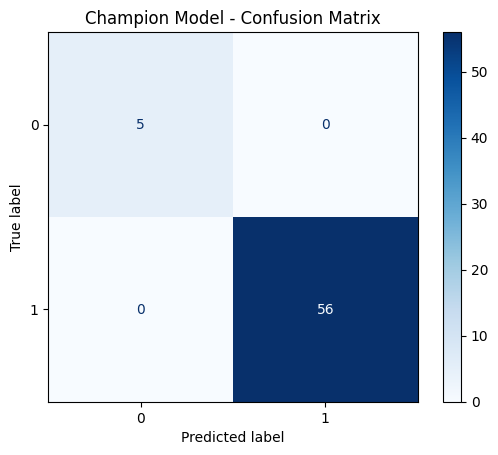

In [52]:
champion_dir = "recording_classifier_models/dense_model/champion_model"
metadata_dir = "recording_classifier_models/dense_model/metadata"

model_path = os.path.join(champion_dir, "champion_model.pt")
info_path = os.path.join(metadata_dir, "champion_info.json")

state_dict = torch.load(model_path, map_location=device)

with open(info_path, "r") as f:
    champion_info = json.load(f)

best_config = champion_info["hyperparameters"]

print(f"Champion model configuration: {best_config}\n")
input_size = x_test.shape[1]

# Rebuild model
model = build_dense_model(best_config, input_size)
model.load_state_dict(state_dict)
model.to(device)

# Summarize model
model_summary = summary(model, input_size=(1, input_size), col_names=["input_size", "output_size", "num_params", "trainable"])

print(model_summary)

model.to(device)
model.eval()
with torch.no_grad():
    logits = model(x_test.to(device))
    probs = torch.sigmoid(logits).cpu().numpy().ravel()

y_true = y_test.cpu().numpy().ravel()

# Metrics
test_auc = roc_auc_score(y_true, probs)
preds = (probs >= 0.5).astype(int)

accuracy = accuracy_score(y_true, preds)
precision = precision_score(y_true, preds, zero_division=0)
recall = recall_score(y_true, preds, zero_division=0)

print("\nTEST EVALUATION DENSE MODEL (Champion Model)")
print(f"AUC: {test_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Champion Model - Confusion Matrix")
plt.show()

## CNN 

In [42]:
def load_and_reshape_all_files(data_dir, n_frames=30, n_features=66):
    """Load all CSV files and reshape them"""
    all_X = []
    all_y = []
    
    for csv_file in os.listdir(data_dir):
        if csv_file.endswith(".csv"):
            df = pd.read_csv(os.path.join(data_dir, csv_file))
            y = df["target"].values
            X_flat = df.drop(columns=["target"]).values
            
            # Reshape
            X = X_flat.reshape(-1, n_frames, n_features)
            
            all_X.append(X)
            all_y.append(y)
    
    # Concatenate all samples
    X_all = np.concatenate(all_X, axis=0)
    y_all = np.concatenate(all_y, axis=0)
    
    return X_all, y_all


def mirror_pose_data(X):
    """
    Mirror pose sequences by swapping left and right body parts.
    
    Args:
        X: numpy array of shape (n_samples, n_frames, 66)
    
    Returns:
        X_mirrored: mirrored version with same shape
    """ 
    # Define left-right pairs (5 features each: x, y, z, visibility, presence)
    left_pairs = [5, 10, 25, 35, 45, 55]  # Start indices of left features
    right_pairs = [15, 20, 30, 40, 50, 60]  # Start indices of right features
    
    X_mirrored = X.copy()
    
    for sample in range(X.shape[0]):
        for frame in range(X.shape[1]):
            # Swap each left-right pair
            for left_start, right_start in zip(left_pairs, right_pairs):
                # Swap all 5 features for this body part
                X_mirrored[sample, frame, left_start:left_start+5] = X[sample, frame, right_start:right_start+5]
                X_mirrored[sample, frame, right_start:right_start+5] = X[sample, frame, left_start:left_start+5]
    
    return X_mirrored

In [43]:
data_dir = "../../MainProject/data/mediapipe_ugly_recordings/"
X, y = load_and_reshape_all_files(data_dir, n_frames=30, n_features=66)
print(f"Total samples: {X.shape[0]}")
print(f"X shape: {X.shape}")  # (total_samples, 30, 66)

y[y == 1] = 0
y[(y == 2) | (y == 3)] = 1

# Then split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

X_train_mirrored = mirror_pose_data(X_train)  # Implement this based on feature swapping
y_train_mirrored = y_train.copy()

# 4. Combine original and mirrored training data
X_train_augmented = np.concatenate([X_train, X_train_mirrored], axis=0)
y_train = np.concatenate([y_train, y_train_mirrored], axis=0)

X_train = X_train_augmented.reshape(X_train_augmented.shape[0], 1, X_train_augmented.shape[1], X_train_augmented.shape[2])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1], X_test.shape[2])



scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1)).reshape(X_train.shape)
X_test  = scaler.transform(X_test.reshape(X_test.shape[0], -1)).reshape(X_test.shape)


x_train = torch.tensor(X_train, dtype=torch.float32).to(device)
x_test  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device).view(-1, 1)


print(f"X_train shape for CNN: {X_train.shape}")  # (n, 1, 30, 66)
print(f"X_test shape for CNN: {X_test.shape}")    # (n, 1, 30, 66)

input_shape = (30, 66)  # (30, 66)
print(f"Input shape for model: {input_shape}")

Total samples: 203
X shape: (203, 30, 66)
X_train shape for CNN: (284, 1, 30, 66)
X_test shape for CNN: (61, 1, 30, 66)
Input shape for model: (30, 66)


In [44]:
class SquatClassifierCNN(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.25):
        """
        Args:
            input_dim: tuple (frames, features) e.g., (30, 66)
        """
        super().__init__()
        frames, features = input_dim
        
        # Calculate output sizes after each layer
        # Input: (batch, 1, 30, 66)
        
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (batch, 32, 30, 66)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),       # (batch, 32, 15, 33)
            nn.Dropout2d(dropout_rate)
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # (batch, 64, 15, 33)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),       # (batch, 64, 7, 16)
            nn.Dropout2d(dropout_rate)
        )
        
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# (batch, 128, 7, 16)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),                # (batch, 128, 1, 1)
            nn.Dropout2d(dropout_rate)
        )
        
        # Classifier (input is 128 from adaptive pooling)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 1)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # x shape: (batch, 1, 30, 66)
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)  # (batch, 128, 1, 1)
        x = x.view(x.size(0), -1)  # Flatten: (batch, 128)
        x = self.classifier(x)
        return x

def build_cnn_model(config, input_dim):
    """Build CNN model with given config"""
    return SquatClassifierCNN(
        input_dim=input_dim, 
        dropout_rate=config.get("dropout", 0.25)
    )

Champion model configuration: {'lr': 0.001, 'dropout': 0, 'epochs': 150}

mps:0
mps:0
Layer (type:depth-idx)                   Output Shape              Param #
SquatClassifierCNN                       [1, 1]                    --
├─Sequential: 1-1                        [1, 32, 15, 33]           --
│    └─Conv2d: 2-1                       [1, 32, 30, 66]           320
│    └─BatchNorm2d: 2-2                  [1, 32, 30, 66]           64
│    └─ReLU: 2-3                         [1, 32, 30, 66]           --
│    └─MaxPool2d: 2-4                    [1, 32, 15, 33]           --
│    └─Dropout2d: 2-5                    [1, 32, 15, 33]           --
├─Sequential: 1-2                        [1, 64, 7, 16]            --
│    └─Conv2d: 2-6                       [1, 64, 15, 33]           18,496
│    └─BatchNorm2d: 2-7                  [1, 64, 15, 33]           128
│    └─ReLU: 2-8                         [1, 64, 15, 33]           --
│    └─MaxPool2d: 2-9                    [1, 64, 7, 16]        

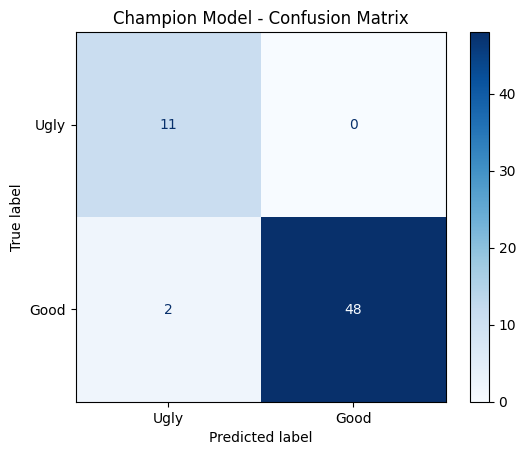

In [45]:
champion_dir = "recording_classifier_models/cnn_model"
metadata_dir = "recording_classifier_models/cnn_model"

model_path = os.path.join(champion_dir, "champion_model.pt")
info_path = os.path.join(metadata_dir, "champion_info.json")

state_dict = torch.load(model_path, map_location=device)

with open(info_path, "r") as f:
    champion_info = json.load(f)

best_config = champion_info["hyperparameters"]

print(f"Champion model configuration: {best_config}\n")

# Rebuild model
model = build_cnn_model(best_config, input_shape)
model.load_state_dict(state_dict)
model.to(device) 

print(next(model.parameters()).device)  # ska visa mps:0
print(x_test.device)                    # ska visa mps:0

# Summarize model
model_summary = summary(model, input_size=(1, 1, input_shape[0], input_shape[1]))

print(model_summary)


model.to(device)
model.eval()

with torch.no_grad():
    logits = model(x_test.to(device))
    probs = torch.sigmoid(logits).cpu().numpy().ravel()

y_true = y_test.cpu().numpy().ravel()

# Metrics
test_auc = roc_auc_score(y_true, probs)
preds = (probs >= 0.5).astype(int)

accuracy = accuracy_score(y_true, preds)
precision = precision_score(y_true, preds, zero_division=0)
recall = recall_score(y_true, preds, zero_division=0)

print("\nTEST EVALUATION CNN MODEL (Champion Model)")
print(f"AUC: {test_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ugly", "Good"])
disp.plot(cmap="Blues")
plt.title("Champion Model - Confusion Matrix")
plt.show()